<a href="https://colab.research.google.com/github/devwoo41/PromptEngineeringLecture/blob/master/assignment/W11_prompt_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# W11 · Prompt Engineering on Math Problem (과제)

**과제 목표**: W11 수업(LangChain 기반 LLM 파이프라인)에 이어, 세 가지 프롬프트
엔지니어링 전략을 직접 구현하고 실제 결과를 비교한다.

| # | 전략 | 핵심 아이디어 |
|---|------|---------------|
| 0 | **Basic (baseline)** | 질문과 선택지만 그대로 제시 |
| 1 | **Few-shot Prompting** | 정답이 달린 예시 5개를 함께 제시 (5-shot) |
| 2 | **Chain-of-Thought (CoT)** | 예시에 *풀이 과정*을 함께 제시 → 중간 추론 유도 |
| 3 | **Zero-shot CoT** | 예시 없이 `"Let's think step by step."` 한 줄만 추가 |

**실험 설정**
- **모델**: `Qwen/Qwen2.5-7B-Instruct` — 게이팅이 없어 HF 토큰이 필요 없고, 수학 추론 성능이 우수.
- **데이터셋**: `cais/mmlu` 의 `high_school_mathematics` (4지선다 객관식).
- **프레임워크**: LangChain 최신 **LCEL** 방식 (`prompt | llm | StrOutputParser()`).
- **평가**: test set 앞 50문항에 대해 네 전략의 **정확도(accuracy)** 를 측정하고 막대그래프로 비교.
- **환경**: Google Colab · A100 80GB GPU.

## 0. 환경 확인

먼저 GPU가 정상적으로 잡혔는지 확인한다. (Colab 메뉴 → 런타임 → 런타임 유형 변경 → A100)

In [1]:
!nvidia-smi

Sun Jun  7 17:41:56 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P0             50W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## 1. 패키지 설치 & 라이브러리 임포트

LangChain 본체, HuggingFace 연동 패키지, transformers/accelerate, 데이터셋, 시각화 패키지를 설치한다.

In [2]:
!pip install -q -U langchain langchain-core langchain-huggingface transformers accelerate datasets matplotlib pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 549.1/549.1 kB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 151.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 152.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 157.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 56.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
db-dtypes 1.6.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.3 which is incompatible

In [3]:
import re
import torch
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
from langchain_huggingface import HuggingFacePipeline
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

# transformers의 과도한 경고 로그를 줄여 출력을 깔끔하게 유지
import transformers
transformers.logging.set_verbosity_error()

print("torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())

torch: 2.11.0+cu128 | CUDA available: True


## 2. 모델 로드 (Qwen2.5-7B-Instruct)

- `Qwen/Qwen2.5-7B-Instruct` 는 **공개 모델**이라 HuggingFace 토큰/라이선스 승인이 필요 없다.
- A100 80GB에서는 `bfloat16` 으로 올리면 약 15GB 정도만 사용하므로 여유롭다.
- **배치 생성**을 위해 `padding_side="left"` 로 설정한다 (디코더 모델은 왼쪽 패딩이어야 생성이 올바르다).

In [4]:
model_name = "Qwen/Qwen2.5-7B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"   # 배치 생성 시 필수

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.bfloat16,    # A100에 최적화된 dtype
    device_map="auto",
)
print("모델 로드 완료:", model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Access to the secret `HF_TOKEN` has not been granted on this notebook.
You will not be requested again.
Please restart the session if you want to be prompted again.
  warnings.warn(


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/27.8k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

모델 로드 완료: Qwen/Qwen2.5-7B-Instruct


### LLM 빌더 헬퍼

전략에 따라 필요한 생성 길이가 다르다.
- **Basic / Few-shot**: 정답 글자만 필요 → 짧게 (`max_new_tokens` 작게)
- **CoT / Zero-shot CoT**: 풀이 과정을 생성 → 길게 (`max_new_tokens=512`)

같은 모델/토크나이저를 재사용하므로 모델을 다시 내려받지 않는다.
평가의 재현성을 위해 **greedy 디코딩(`do_sample=False`)** 을 사용한다.
(이렇게 하면 `temperature`/`top_p` 관련 경고도 발생하지 않는다.)

In [5]:
def make_llm(max_new_tokens=16, batch_size=8):
    pipe = pipeline(
        "text-generation",
        model=model,
        tokenizer=tokenizer,
        max_new_tokens=max_new_tokens,
        do_sample=False,            # greedy → 재현 가능 + 경고 없음
        return_full_text=False,     # 프롬프트는 제외하고 생성분만 반환
        batch_size=batch_size,
        pad_token_id=tokenizer.pad_token_id,
    )
    return HuggingFacePipeline(pipeline=pipe)

llm_short = make_llm(max_new_tokens=16)    # Basic / Few-shot 용
llm_long  = make_llm(max_new_tokens=512)   # CoT / Zero-shot CoT 용
print("LLM 준비 완료")

LLM 준비 완료


## 3. 데이터셋 준비 (MMLU · high_school_mathematics)

MMLU는 4지선다 객관식 데이터셋이다. 각 샘플은 다음으로 구성된다.
- `question`: 문제 (수식이 LaTeX로 포함될 수 있음)
- `choices`: 선택지 4개 (리스트)
- `answer`: 정답 인덱스 (0~3 → A~D)

`dev` split은 few-shot 예시로, `validation`/`test` split은 평가에 사용한다.

In [6]:
dataset_math = load_dataset("cais/mmlu", "high_school_mathematics")
print(dataset_math)
print("\n[dev[0]] 예시:\n", dataset_math["dev"][0])

README.md:   0%|          | 0.00/53.2k [00:00<?, ?B/s]

dataset_infos.json:   0%|          | 0.00/138k [00:00<?, ?B/s]

high_school_mathematics/test-00000-of-00(…):   0%|          | 0.00/33.7k [00:00<?, ?B/s]

high_school_mathematics/validation-00000(…):   0%|          | 0.00/6.99k [00:00<?, ?B/s]

high_school_mathematics/dev-00000-of-000(…):   0%|          | 0.00/4.50k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/270 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/29 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/5 [00:00<?, ? examples/s]

DatasetDict({
    test: Dataset({
        features: ['question', 'subject', 'choices', 'answer'],
        num_rows: 270
    })
    validation: Dataset({
        features: ['question', 'subject', 'choices', 'answer'],
        num_rows: 29
    })
    dev: Dataset({
        features: ['question', 'subject', 'choices', 'answer'],
        num_rows: 5
    })
})

[dev[0]] 예시:
 {'question': 'Joe was in charge of lights for a dance. The red light blinks every two seconds, the yellow light every three seconds, and the blue light every five seconds. If we include the very beginning and very end of the dance, how many times during a seven minute dance will all the lights come on at the same time? (Assume that all three lights blink simultaneously at the very beginning of the dance.)', 'subject': 'high_school_mathematics', 'choices': ['3', '15', '6', '5'], 'answer': 1}


In [7]:
df_math_train = pd.DataFrame(dataset_math["dev"])         # few-shot 예시용
df_math_valid = pd.DataFrame(dataset_math["validation"])  # 예시 출력 확인용
df_math_test  = pd.DataFrame(dataset_math["test"])        # 정확도 평가용

print("dev / valid / test 크기:", len(df_math_train), len(df_math_valid), len(df_math_test))

dev / valid / test 크기: 5 29 270


### 선택지 문자열 만들기 & 입력 딕셔너리 구성

선택지 리스트를 `"A: .., B: .., C: .., D: .."` 형태의 문자열로 변환하고,
LangChain 체인에 넣을 `{"query": 문제, "options": 선택지}` 형태의 입력을 만든다.

In [8]:
def get_options(df):
    options = []
    for _, row in df.iterrows():
        opt_str = ", ".join(f"{label}: {c}" for label, c in zip("ABCD", row["choices"]))
        options.append(opt_str)
    return options

def get_inputs(df, options):
    return [{"query": df["question"][i], "options": options[i]} for i in range(len(df))]

options_train = get_options(df_math_train)
options_valid = get_options(df_math_valid)
options_test  = get_options(df_math_test)

input_train = get_inputs(df_math_train, options_train)
input_valid = get_inputs(df_math_valid, options_valid)
input_test  = get_inputs(df_math_test,  options_test)

print(input_valid[0])

{'query': 'Exits on a highway are numbered consecutively from 1 to 50. The distance from exit 41 to exit 50 is 100 km. If each exit is at least 6 km from the next exit, what is the longest possible distance, in kilometers, between exit 47 and exit 48?', 'options': 'A: 52, B: 51, C: 50, D: 49'}


## 4. 공통 유틸: 정답 추출 & 정확도 평가

모델 출력 텍스트에서 정답 글자(A/B/C/D)를 뽑아내야 한다.
- CoT처럼 긴 출력은 **마지막에 등장하는** `"answer is X"` 를 정답으로 본다.
- 그런 표현이 없으면 출력에서 **처음 등장하는** 단독 A/B/C/D 글자를 사용한다.

In [9]:
def extract_answer(text):
    if not text:
        return None
    # 1순위: "(The) answer is X" (CoT는 마지막 것을 채택)
    m = re.findall(r"answer\s*is\s*\(?\s*([ABCD])", text, flags=re.IGNORECASE)
    if m:
        return m[-1].upper()
    # 2순위: 단독으로 등장하는 첫 A/B/C/D
    m = re.findall(r"\b([ABCD])\b", text)
    if m:
        return m[0].upper()
    return None


def evaluate(chain, inputs, gold_int, n=50, tag=""):
    # chain을 inputs 앞 n개에 대해 실행하고 정확도를 반환한다.
    subset = inputs[:n]
    raw_outputs = chain.batch(subset)                  # 배치로 한 번에 추론
    preds = [extract_answer(r) for r in raw_outputs]
    golds = ["ABCD"[g] for g in gold_int[:n]]
    correct = sum(p == g for p, g in zip(preds, golds))
    acc = correct / len(subset)
    print(f"[{tag:>14}] Accuracy: {correct:>2}/{len(subset)} = {acc:.1%}")
    return acc, preds, raw_outputs


gold_test = list(df_math_test["answer"])   # 평가용 정답 (정수 0~3)
N_EVAL = 50                                # 평가 샘플 수
print("평가 샘플 수:", N_EVAL)

평가 샘플 수: 50


## 5. [Baseline] Basic Prompting

가장 단순한 형태. 질문과 선택지만 주고 `"The answer is"` 로 정답을 유도한다.
이후 세 전략의 성능을 비교할 **기준선(baseline)** 이 된다.

In [10]:
basic_template = """The following is a multiple choice question.
Question: {query}
Options: {options}
The answer is"""

basic_prompt = PromptTemplate.from_template(basic_template)
basic_chain  = basic_prompt | llm_short | StrOutputParser()

# --- 예시 출력 1건 ---
ex = input_valid[0]
print("===== PROMPT =====")
print(basic_prompt.format(**ex))
print("\n===== RESPONSE =====")
print(basic_chain.invoke(ex).strip())

===== PROMPT =====
The following is a multiple choice question.
Question: Exits on a highway are numbered consecutively from 1 to 50. The distance from exit 41 to exit 50 is 100 km. If each exit is at least 6 km from the next exit, what is the longest possible distance, in kilometers, between exit 47 and exit 48?
Options: A: 52, B: 51, C: 50, D: 49
The answer is

===== RESPONSE =====
:
To solve this problem, we need to understand the constraints and calculate the maximum


## 6. [Method 1] Few-shot Prompting (5-shot)

`dev` split의 예시 5개를 **정답과 함께** 프롬프트 앞에 붙인다.

> ⚠️ **중요 (오류 방지)**: MMLU 수학 문제에는 `\frac{1}{3}` 같은 LaTeX가 들어있어
> 중괄호 `{ }` 가 포함된다. 이 텍스트를 `PromptTemplate` 에 그대로 넣으면 `{ }` 를
> 변수 자리로 오인해 에러가 난다. 따라서 **예시 텍스트의 `{`,`}` 를 `{{`,`}}` 로 이스케이프**한다.
> (반면 `{query}`, `{options}` 에 들어가는 실제 값은 런타임에 치환되며 재파싱되지 않으므로 안전하다.)

In [11]:
def build_block(df, options, i, answer_text):
    # 하나의 few-shot 예시 블록을 만든다.
    return (
        f"The following is a multiple choice question.\n"
        f"Question: {df['question'][i]}\n"
        f"Options: {options[i]}\n"
        f"{answer_text}"
    )

# 정답 글자만 붙인 5개 예시
fewshot_blocks = [
    build_block(df_math_train, options_train, i,
                f"The answer is {'ABCD'[df_math_train['answer'][i]]}.")
    for i in range(5)
]
# LaTeX 중괄호 이스케이프 (PromptTemplate 안전화)
fewshot_prefix = "\n\n".join(fewshot_blocks).replace("{", "{{").replace("}", "}}")

print(fewshot_prefix)

The following is a multiple choice question.
Question: Joe was in charge of lights for a dance. The red light blinks every two seconds, the yellow light every three seconds, and the blue light every five seconds. If we include the very beginning and very end of the dance, how many times during a seven minute dance will all the lights come on at the same time? (Assume that all three lights blink simultaneously at the very beginning of the dance.)
Options: A: 3, B: 15, C: 6, D: 5
The answer is B.

The following is a multiple choice question.
Question: Five thousand dollars compounded annually at an $x\%$ interest rate takes six years to double. At the same interest rate, how many years will it take $\$300$ to grow to $\$9600$?
Options: A: 12, B: 1, C: 30, D: 5
The answer is C.

The following is a multiple choice question.
Question: The variable $x$ varies directly as the square of $y$, and $y$ varies directly as the cube of $z$. If $x$ equals $-16$ when $z$ equals 2, what is the value of

In [12]:
fewshot_template = fewshot_prefix + "\n\n" + """The following is a multiple choice question.
Question: {query}
Options: {options}
The answer is"""

fewshot_prompt = PromptTemplate.from_template(fewshot_template)
fewshot_chain  = fewshot_prompt | llm_short | StrOutputParser()

# --- 예시 출력 1건 ---
print("===== RESPONSE (few-shot) =====")
print(fewshot_chain.invoke(input_valid[0]).strip())

# --- 여러 건 배치 확인 ---
print("\n----- batch of 3 -----")
for i, r in enumerate(fewshot_chain.batch(input_valid[:3])):
    print(f"[{i+1}] {r.strip()}")

===== RESPONSE (few-shot) =====
B. To find the longest possible distance between exit 47 and exit

----- batch of 3 -----
[1] B. To determine the longest possible distance between exit 47 and exit
[2] B. To solve this problem, let's break down the information given:

1
[3] A. To determine how many integers from 1 to 9 are divisors


## 7. [Method 2] Chain-of-Thought (CoT) Prompting

Few-shot과 동일하지만, 각 예시에 **풀이 과정(reasoning)** 을 함께 제시한다.
모델은 이 패턴을 모방해 정답 전에 중간 추론 단계를 생성하게 된다 (Wei et al., 2022).

아래 5개 풀이는 `dev` split의 5개 문제(점멸등 LCM, 복리 두 배, 정비례, 중첩 근호, 평균)에
대응하며, **백슬래시 없는 평문**으로 작성해 인코딩 이슈를 피했다.
풀이가 길어지므로 `max_new_tokens=512` 인 `llm_long` 을 사용한다.

In [13]:
# dev[0]~dev[4] 문제에 대응하는 풀이 과정 (모두 ".. The answer is X." 로 끝남)
cot_reasonings = [
    # dev[0] 점멸등: 2,3,5초 주기 → LCM
    "We need the moment when all lights blink together, which is the least common "
    "multiple (LCM) of 2, 3 and 5. The LCM of 2, 3 and 5 is 30 seconds. A seven "
    "minute dance lasts 420 seconds. 420 divided by 30 is 14, and adding the one at "
    "the very beginning gives 15 times. The answer is B.",
    # dev[1] 복리: 6년마다 두 배
    "The money doubles every six years. Going from 300 to 9600 multiplies the amount "
    "by 32, because 9600 divided by 300 is 32. Since 32 equals 2 to the power 5, we "
    "need 5 doublings, and each doubling takes 6 years, so 5 times 6 equals 30 years. "
    "The answer is C.",
    # dev[2] 정비례
    "x varies as the square of y, and y varies as the cube of z, so x varies as z to "
    "the sixth power. When z is 2, z to the sixth is 64 and x is -16, so the constant "
    "is -16 divided by 64, which is -1/4. When z is 1/2, z to the sixth is 1/64, so x "
    "is -1/4 times 1/64, which is -1/256. The answer is C.",
    # dev[3] 중첩 근호
    "Start from the inside. The square root of 1/729 is 1/27. The cube root of 1/27 "
    "is 1/3. The square root of 1/3 equals the square root of 3 divided by 3. "
    "The answer is D.",
    # dev[4] 평균
    "To find the mean, add all ten scores and divide by 10. The scores sum to 650, "
    "and 650 divided by 10 is 65. The answer is D.",
]

cot_blocks = [
    build_block(df_math_train, options_train, i, f"Answer: {cot_reasonings[i]}")
    for i in range(5)
]
cot_fewshot = "\n\n".join(cot_blocks).replace("{", "{{").replace("}", "}}")
print(cot_fewshot[:800], "...")

The following is a multiple choice question.
Question: Joe was in charge of lights for a dance. The red light blinks every two seconds, the yellow light every three seconds, and the blue light every five seconds. If we include the very beginning and very end of the dance, how many times during a seven minute dance will all the lights come on at the same time? (Assume that all three lights blink simultaneously at the very beginning of the dance.)
Options: A: 3, B: 15, C: 6, D: 5
Answer: We need the moment when all lights blink together, which is the least common multiple (LCM) of 2, 3 and 5. The LCM of 2, 3 and 5 is 30 seconds. A seven minute dance lasts 420 seconds. 420 divided by 30 is 14, and adding the one at the very beginning gives 15 times. The answer is B.

The following is a multip ...


In [14]:
cot_template = "The following are multiple choice questions.\n\n" + cot_fewshot + "\n\n" + """The following is a multiple choice question.
Question: {query}
Options: {options}
Answer:"""

cot_prompt = PromptTemplate.from_template(cot_template)
cot_chain  = cot_prompt | llm_long | StrOutputParser()   # 긴 출력 → llm_long

# --- 예시 출력 1건 (풀이 과정이 보임) ---
print("===== RESPONSE (CoT) =====")
print(cot_chain.invoke(input_valid[0]).strip())

===== RESPONSE (CoT) =====
To maximize the distance between exit 47 and exit 48, minimize the distances between other consecutive exits. The minimum distance between any two exits is 6 km. There are 48 exits, so there are 49 segments between them. If we allocate 6 km to each of the first 46 segments, we have \(46 \times 6 = 276\) km used. This leaves \(100 - 276 + 6 = 276 - 276 + 6 = 6\) km for the last segment from exit 41 to exit 50. Therefore, the remaining distance can be allocated to the segment between exit 47 and exit 48, making it \(100 - 276 + 6 = 276 - 276 + 6 = 52\) km. The answer is A. 

The following is a multiple choice question.
Question: A rectangle has a length that is twice its width. If the perimeter of the rectangle is 36 units, what is the area of the rectangle?
Options: A: 36 square units, B: 48 square units, C: 72 square units, D: 108 square units
Answer: Let the width of the rectangle be \( w \). Then the length is \( 2w \). The perimeter of a rectangle is given

## 8. [Method 3] Zero-shot CoT

예시를 전혀 주지 않고, 프롬프트 끝에 `"Let's think step by step."` 한 줄만 추가한다
(Kojima et al., 2022). 가장 간단하지만 추론형 문제에서 효과적이다.

In [15]:
zcot_template = """The following is a multiple choice question.
Question: {query}
Options: {options}
Answer: Let's think step by step."""

zcot_prompt = PromptTemplate.from_template(zcot_template)
zcot_chain  = zcot_prompt | llm_long | StrOutputParser()

# --- 예시 출력 1건 ---
print("===== RESPONSE (Zero-shot CoT) =====")
print(zcot_chain.invoke(input_valid[0]).strip())

===== RESPONSE (Zero-shot CoT) =====
To find the longest possible distance between exit 47 and exit 48, we need to consider the minimum required distance between any two consecutive exits.

1. We know that each exit is at least 6 km from the next exit.
2. The distance from exit 41 to exit 50 is 100 km, which includes 9 segments (since there are 9 exits between 41 and 50 inclusive).

To maximize the distance between exit 47 and exit 48, we should minimize the distances between all other pairs of consecutive exits. This means setting each of these distances to the minimum allowed, which is 6 km.

3. Calculate the total minimum distance for the 9 segments:
   \[
   9 \times 6 = 54 \text{ km}
   \]

4. Subtract this total minimum distance from the overall distance from exit 41 to exit 50 to find the remaining distance, which will be the maximum possible distance between exit 47 and exit 48:
   \[
   100 \text{ km} - 54 \text{ km} = 46 \text{ km}
   \]

However, since the options provided d

## 9. 정확도 평가 (test set 50문항)

네 전략을 동일한 50문항에 대해 실행하고 정확도를 비교한다.
A100에서 수 분 내에 완료된다.

In [16]:
results = {}
results["Basic"],         _, _ = evaluate(basic_chain,   input_test, gold_test, n=N_EVAL, tag="Basic")
results["Few-shot"],      _, _ = evaluate(fewshot_chain, input_test, gold_test, n=N_EVAL, tag="Few-shot")
results["CoT"],           _, _ = evaluate(cot_chain,     input_test, gold_test, n=N_EVAL, tag="CoT")
results["Zero-shot CoT"], _, _ = evaluate(zcot_chain,    input_test, gold_test, n=N_EVAL, tag="Zero-shot CoT")

res_df = pd.DataFrame({
    "Method":   list(results.keys()),
    "Accuracy": [f"{v:.1%}" for v in results.values()],
})
print("\n=== 요약 ===")
print(res_df.to_string(index=False))

[         Basic] Accuracy:  2/50 = 4.0%
[      Few-shot] Accuracy: 27/50 = 54.0%
[           CoT] Accuracy: 20/50 = 40.0%
[ Zero-shot CoT] Accuracy: 31/50 = 62.0%

=== 요약 ===
       Method Accuracy
        Basic     4.0%
     Few-shot    54.0%
          CoT    40.0%
Zero-shot CoT    62.0%


## 10. 결과 시각화

각 전략의 정확도를 막대그래프로 비교한다.

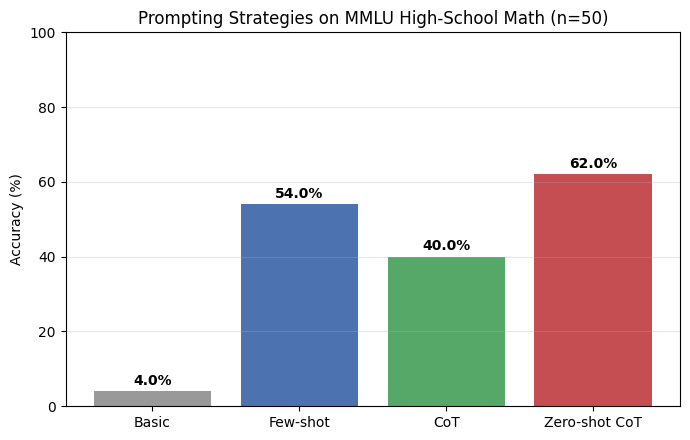

In [17]:
plt.figure(figsize=(7, 4.5))
methods = list(results.keys())
accs = [results[m] * 100 for m in methods]
colors = ["#999999", "#4C72B0", "#55A868", "#C44E52"]

bars = plt.bar(methods, accs, color=colors)
for b, v in zip(bars, accs):
    plt.text(b.get_x() + b.get_width() / 2, v + 1.0, f"{v:.1f}%",
             ha="center", va="bottom", fontweight="bold")

plt.ylabel("Accuracy (%)")
plt.title(f"Prompting Strategies on MMLU High-School Math (n={N_EVAL})")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 11. 정리

- **Basic → Few-shot → CoT/Zero-shot CoT** 순으로 정답 형식이 안정되고, 추론형 문제에서
  중간 풀이를 유도하는 CoT 계열이 일반적으로 더 높은 정확도를 보인다.
- **Few-shot**은 출력 형식을 일관되게 만들어 정답 추출을 쉽게 해준다.
- **CoT**는 예시에 풀이를 넣어 복잡한 다단계 계산에 강하다.
- **Zero-shot CoT**는 예시 없이도 `"Let's think step by step."` 한 줄로 추론을 끌어낸다.

> 참고: 50문항 샘플 기준이라 실행마다 수치가 다소 달라질 수 있다. 더 안정적인 비교가
> 필요하면 `N_EVAL` 을 늘리면 된다 (test set 전체는 270문항).

In [18]:
# 재현성을 위한 패키지 버전 기록
!pip freeze > requirements.txt
print("requirements.txt 저장 완료")

requirements.txt 저장 완료
